In [11]:
import os
from pathlib import Path

# Colab: Runtime → Secrets → add KAGGLE_USERNAME and KAGGLE_KEY (from Kaggle → Account → API).
try:
    from google.colab import userdata  # type: ignore[import-not-found]
except ImportError:
    userdata = None

IN_COLAB = userdata is not None

if IN_COLAB:
    for key in ("KAGGLE_USERNAME", "KAGGLE_KEY"):
        try:
            val = userdata.get(key)
        except Exception:
            val = None
        if val:
            os.environ[key] = val

if IN_COLAB:
    OUTPUT_DATA_DIR = Path("/content/data/bbc")
else:
    OUTPUT_DATA_DIR = Path("../data/bbc")

print("Running in Colab:", IN_COLAB)
print("CSV output directory:", OUTPUT_DATA_DIR.resolve())

Running in Colab: False
CSV output directory: D:\llm_doc_classification\data\bbc


In [12]:
from pathlib import Path

import kagglehub

path = kagglehub.dataset_download("shivamkushwaha/bbc-full-text-document-classification")
print("Path to dataset files:", path)
dataset_path = Path(path) / "bbc"
print("BBC folder:", dataset_path)


Path to dataset files: C:\Users\aram_\.cache\kagglehub\datasets\shivamkushwaha\bbc-full-text-document-classification\versions\1
BBC folder: C:\Users\aram_\.cache\kagglehub\datasets\shivamkushwaha\bbc-full-text-document-classification\versions\1\bbc


In [13]:
assert dataset_path.is_dir(), f"Expected BBC dataset folder at {dataset_path}"
print(dataset_path)


C:\Users\aram_\.cache\kagglehub\datasets\shivamkushwaha\bbc-full-text-document-classification\versions\1\bbc


In [14]:
labels = [p.name for p in dataset_path.iterdir() if p.is_dir()]
print("Labels:", labels)

Labels: ['business', 'entertainment', 'politics', 'sport', 'tech']


In [15]:
for label in labels:
    print(f"\n===== {label.upper()} =====")
    
    files = list((dataset_path / label).glob("*.txt"))[:2]  # only 2 samples
    
    for file_path in files:
        with open(file_path, "r", encoding="latin-1") as f:
            text = f.read()
        
        print(f"\n--- Sample ---\n{text[:300]}")
        


===== BUSINESS =====

--- Sample ---
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and high

--- Sample ---
Dollar gains on Greenspan speech

The dollar has hit its highest level against the euro in almost three months after the Federal Reserve head said the US trade deficit is set to stabilise.

And Alan Greenspan highlighted the US government's willingness to curb spending and rising household savings a

===== ENTERTAINMENT =====

--- Sample ---
Gallery unveils interactive tree

A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.

The spruce has an antenna which can receive Bluetooth texts sent by visitors to the Tate. The messages will be "unwrapped" by sculptor Richard Wentworth, who is 


In [16]:
import pandas as pd

rows = []
for label in labels:
    for file_path in (dataset_path / label).glob("*.txt"):
        with open(file_path, "r", encoding="latin-1") as f:
            text = f.read()
        rows.append({"label": label, "text": text})

df = pd.DataFrame(rows)
print(df.shape)
print(df["label"].value_counts().sort_index())

(2225, 2)
label
business         510
entertainment    386
politics         417
sport            511
tech             401
Name: count, dtype: int64


In [17]:
label2id = {label: i for i, label in enumerate(sorted(df["label"].unique()))}
id2label = {i: label for label, i in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print(label2id)


{'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


In [18]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (1780, 3)
Val: (222, 3)
Test: (223, 3)


In [19]:
output_dir = OUTPUT_DATA_DIR
output_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(output_dir / "train.csv", index=False)
val_df.to_csv(output_dir / "val.csv", index=False)
test_df.to_csv(output_dir / "test.csv", index=False)

print("Saved to:", output_dir.resolve())


Saved to: D:\llm_doc_classification\data\bbc


## Exploratory data analysis

Summary statistics and plots for the full corpus (`df`) and a quick check that train/validation/test splits preserve class proportions.

In [21]:
%pip install matplotlib seaborn -q

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

eda_df = df.copy()
eda_df["char_len"] = eda_df["text"].str.len()
eda_df["word_len"] = eda_df["text"].str.split().str.len()

print("Length statistics (characters and words):")
print(eda_df[["char_len", "word_len"]].describe().round(1).to_string())
print("\nDocuments per class:")
print(eda_df["label"].value_counts().sort_index().to_string())

Note: you may need to restart the kernel to use updated packages.
Length statistics (characters and words):
       char_len  word_len
count    2225.0    2225.0
mean     2265.8     384.0
std      1364.3     238.2
min       503.0      89.0
25%      1448.0     246.0
50%      1967.0     332.0
75%      2804.0     471.0
max     25485.0    4432.0

Documents per class:
label
business         510
entertainment    386
politics         417
sport            511
tech             401


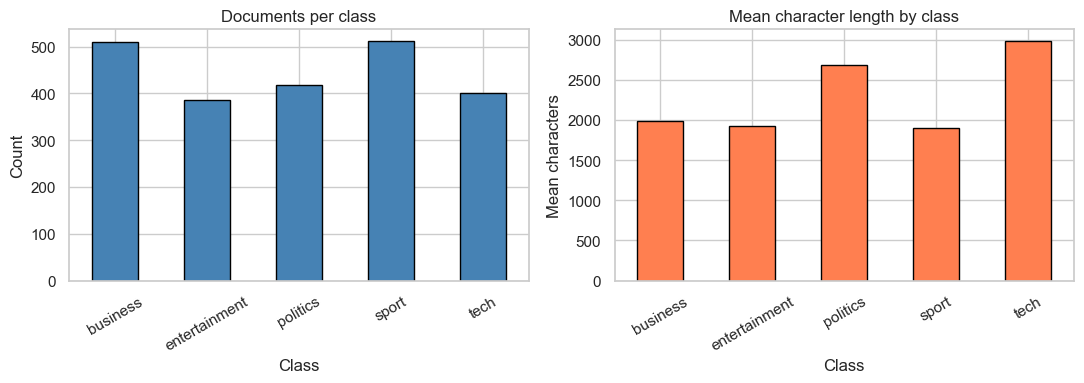

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
eda_df["label"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="black"
)
ax.set_title("Documents per class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
eda_df.groupby("label")["char_len"].mean().sort_index().plot(
    kind="bar", ax=ax, color="coral", edgecolor="black"
)
ax.set_title("Mean character length by class")
ax.set_xlabel("Class")
ax.set_ylabel("Mean characters")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

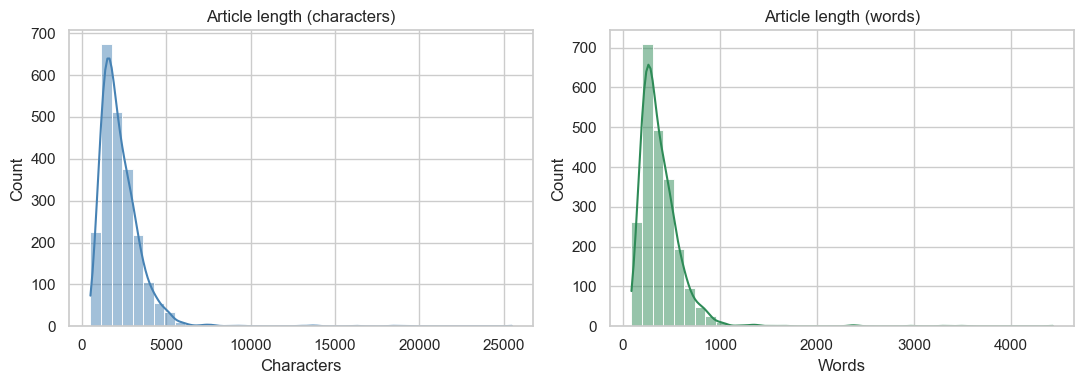

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
sns.histplot(eda_df, x="char_len", bins=40, kde=True, ax=ax, color="steelblue")
ax.set_title("Article length (characters)")
ax.set_xlabel("Characters")

ax = axes[1]
sns.histplot(eda_df, x="word_len", bins=40, kde=True, ax=ax, color="seagreen")
ax.set_title("Article length (words)")
ax.set_xlabel("Words")

plt.tight_layout()
plt.show()

C:\Users\aram_\AppData\Local\Temp\ipykernel_20816\3607591583.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="label", y="char_len", order=order, ax=ax, palette="pastel")


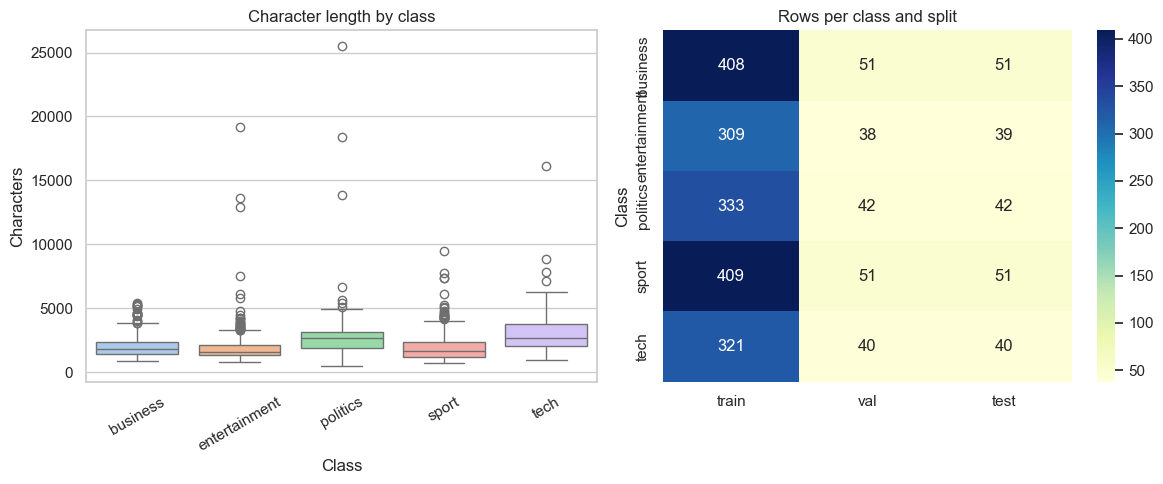

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
order = sorted(eda_df["label"].unique())
sns.boxplot(data=eda_df, x="label", y="char_len", order=order, ax=ax, palette="pastel")
ax.set_title("Character length by class")
ax.set_xlabel("Class")
ax.set_ylabel("Characters")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
split_tbl = pd.DataFrame(
    {
        "train": train_df["label"].value_counts(),
        "val": val_df["label"].value_counts(),
        "test": test_df["label"].value_counts(),
    }
).fillna(0).astype(int)
split_tbl = split_tbl.reindex(order)
sns.heatmap(split_tbl, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Rows per class and split")
ax.set_ylabel("Class")

plt.tight_layout()
plt.show()